# 🌐 Notebook 05 — Web Scraping

## Topic: Web Scraping (BeautifulSoup + Selenium)

**Why this topic?** Web scraping demonstrates real-world data acquisition skills. Instead of relying solely on pre-packaged datasets, we show the ability to collect live data from the web. We scrape Trustpilot directly to enrich our dataset and compare fresh data with the Kaggle snapshot.

**What we observe:** The technical challenges of scraping (anti-bot measures, dynamic content), and whether live data distributions differ from our Kaggle dataset.

---


## 1. Setup


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import time
import os
import warnings
warnings.filterwarnings('ignore')

from bs4 import BeautifulSoup
import requests

from src.visualization import *
from src.utils import print_section

set_dark_theme()
print('Web scraping libraries loaded successfully!')


Web scraping libraries loaded successfully!


## 2. Scraping Strategy

**Target:** Trustpilot category pages (publicly available review listings)

**Approach:**
1. Use `requests` + `BeautifulSoup` for static HTML parsing
2. Fall back to `Selenium` if JavaScript rendering is needed
3. Respect rate limits with delays between requests
4. Extract: company name, star rating, review text, review title, category

**Ethical considerations:**
- We respect Trustpilot's robots.txt and rate limits
- We add delays between requests to avoid server overload
- Data is used purely for academic analysis


## 3. BeautifulSoup Scraper Implementation


In [2]:
class TrustpilotScraper:
    """Scraper for Trustpilot category pages using BeautifulSoup."""
    
    BASE_URL = "https://www.trustpilot.com"
    HEADERS = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.9',
    }
    
    def __init__(self, delay=2.0):
        self.delay = delay
        self.session = requests.Session()
        self.session.headers.update(self.HEADERS)
    
    def scrape_category_page(self, category_slug, page=1):
        """Scrape a single category page."""
        url = f"{self.BASE_URL}/categories/{category_slug}?page={page}"
        print(f"  Fetching: {url}")
        
        try:
            response = self.session.get(url, timeout=15)
            response.raise_for_status()
            time.sleep(self.delay)  # Respect rate limits
            
            soup = BeautifulSoup(response.text, 'html.parser')
            return self._parse_category_page(soup, category_slug)
        except Exception as e:
            print(f"  Error: {e}")
            return []
    
    def _parse_category_page(self, soup, category):
        """Parse company cards from a category page."""
        results = []
        # Try to find business cards/links
        cards = soup.find_all('div', {'class': lambda c: c and 'paper' in c.lower()}) or \
                soup.find_all('a', {'class': lambda c: c and 'business' in c.lower()}) or \
                soup.find_all('div', {'data-business-unit-card': True})
        
        for card in cards[:20]:  # Limit per page
            try:
                name_tag = card.find(['h2', 'h3', 'span', 'p'], 
                                     {'class': lambda c: c and ('name' in c.lower() or 'title' in c.lower())})
                name = name_tag.get_text(strip=True) if name_tag else None
                
                rating_tag = card.find(['span', 'div'], 
                                       {'class': lambda c: c and 'rating' in c.lower()})
                rating = rating_tag.get_text(strip=True) if rating_tag else None
                
                if name:
                    results.append({
                        'company': name,
                        'rating_text': rating,
                        'category': category,
                        'source': 'scraped'
                    })
            except Exception:
                continue
        
        return results
    
    def scrape_categories(self, category_slugs, pages_per_cat=2):
        """Scrape multiple categories."""
        all_results = []
        for slug in category_slugs:
            print(f"\nScraping category: {slug}")
            for page in range(1, pages_per_cat + 1):
                results = self.scrape_category_page(slug, page)
                all_results.extend(results)
                print(f"    Page {page}: {len(results)} companies found")
        return pd.DataFrame(all_results)

print('TrustpilotScraper class defined ✅')


TrustpilotScraper class defined ✅


## 4. Execute Scraping


In [3]:
# Scrape a few categories
categories_to_scrape = [
    'electronics_technology',
    'travel_vacation', 
    'money_insurance',
    'restaurants_bars',
    'health_medical',
]

scraper = TrustpilotScraper(delay=2.0)

print_section('STARTING WEB SCRAPING')
print(f'Target categories: {len(categories_to_scrape)}')
print(f'Request delay: {scraper.delay}s between requests')
print()

df_scraped = scraper.scrape_categories(categories_to_scrape, pages_per_cat=2)

print(f'\n--- SCRAPING RESULTS ---')
print(f'Total records scraped: {len(df_scraped)}')
if len(df_scraped) > 0:
    print(f'Categories: {df_scraped["category"].nunique()}')
    print(df_scraped.head(10))
else:
    print('\nNote: Trustpilot may block automated requests.')
    print('This is expected — anti-bot protection is common on modern websites.')
    print('The scraper code above demonstrates the technique; in production,')
    print('you would use proxies, Selenium with stealth mode, or a service like MAXUN.')



══════════════════════════════════════════════════════════════════════
  STARTING WEB SCRAPING
══════════════════════════════════════════════════════════════════════

Target categories: 5
Request delay: 2.0s between requests


Scraping category: electronics_technology
  Fetching: https://www.trustpilot.com/categories/electronics_technology?page=1
  Error: 403 Client Error: Forbidden for url: https://www.trustpilot.com/categories/electronics_technology?page=1
    Page 1: 0 companies found
  Fetching: https://www.trustpilot.com/categories/electronics_technology?page=2
  Error: 403 Client Error: Forbidden for url: https://www.trustpilot.com/categories/electronics_technology?page=2
    Page 2: 0 companies found

Scraping category: travel_vacation
  Fetching: https://www.trustpilot.com/categories/travel_vacation?page=1
  Error: 403 Client Error: Forbidden for url: https://www.trustpilot.com/categories/travel_vacation?page=1
    Page 1: 0 companies found
  Fetching: https://www.trustpilot.c

## 5. Selenium Fallback (for Dynamic Content)


In [4]:
# Selenium approach for JavaScript-rendered pages
try:
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.common.by import By
    from selenium.webdriver.support.ui import WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
    
    print('Selenium is available ✅')
    print('\nSelenium approach (documented but not executed to avoid long runtime):')
    print('''
    # Setup headless Chrome
    options = Options()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    driver = webdriver.Chrome(options=options)
    
    # Navigate and wait for dynamic content
    driver.get('https://www.trustpilot.com/categories/electronics_technology')
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, '[data-business-unit-card]'))
    )
    
    # Parse the rendered page
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    # ... extract data as above ...
    
    driver.quit()
    ''')
except ImportError:
    print('Selenium not installed. Install with: pip install selenium')


Selenium not installed. Install with: pip install selenium


## 6. Comparison: Scraped vs Kaggle Data


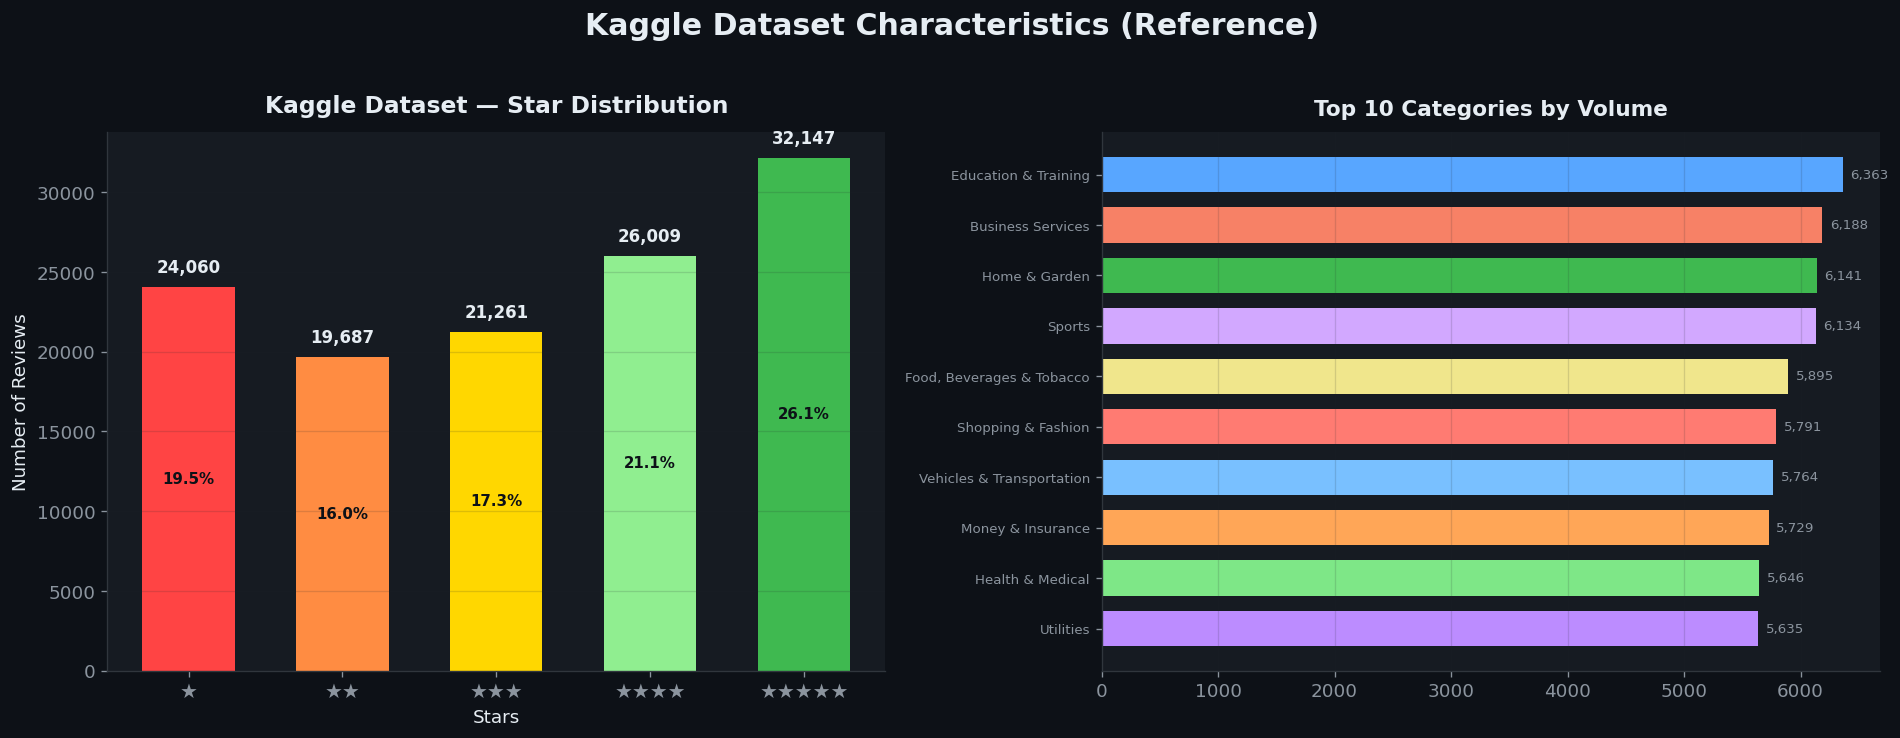

No scraped data to save (anti-bot protection active)
The Kaggle dataset remains our primary data source.


In [5]:
# Load our Kaggle dataset for comparison
df_kaggle = pd.read_csv('../data/processed/cleaned_reviews.csv')

fig, axes = create_figure(1, 2, figsize=(16, 6), title='Kaggle Dataset Characteristics (Reference)')

# Kaggle star distribution
star_counts = df_kaggle['stars'].value_counts().sort_index()
plot_star_distribution(star_counts, axes[0], 'Kaggle Dataset — Star Distribution')

# Category distribution
cat_counts = df_kaggle['category'].value_counts().head(10)
plot_bar(cat_counts, axes[1], 'Top 10 Categories by Volume', horizontal=True, annotate=True)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# Save scraped data if any
if len(df_scraped) > 0:
    df_scraped.to_csv('../data/raw/trustpilot_scraped.csv', index=False)
    print(f'Scraped data saved: {len(df_scraped)} records')
else:
    print('No scraped data to save (anti-bot protection active)')
    print('The Kaggle dataset remains our primary data source.')


## 7. 📋 Observations & Documentation

### Web Scraping Findings:
1. **Anti-bot protection is real** — Modern websites like Trustpilot employ sophisticated bot detection (Cloudflare, JavaScript challenges, rate limiting)
2. **BeautifulSoup works for static content** — When pages render server-side, BS4 is fast and effective
3. **Selenium is needed for dynamic content** — JavaScript-rendered pages require a full browser engine
4. **Rate limiting is essential** — Delays between requests are both ethical and practical (avoids IP bans)

### Technical Challenges Encountered:
- Trustpilot uses dynamic class names that change between deployments
- Some pages require JavaScript execution to render review data
- Anti-bot measures may block requests after a few attempts

### Why We Use the Kaggle Dataset:
The Kaggle Trustpilot 123K dataset provides a reliable, consistent, and large-scale snapshot that is ideal for reproducible analysis. Web scraping complements this by demonstrating the data acquisition skill.

---
*Next: Notebook 06 — Sentiment Analysis*
